In [2]:
import matplotlib.pyplot as plt
import matplotlib
font = matplotlib.font_manager.FontProperties(fname='SimSun.ttf',size = 10)
import pandas as pd
import json
import numpy as np
import jieba
import os
import wordcloud
from wordcloud import WordCloud
from PIL import Image
from collections import Counter

with open(f'data/clean_sentence.txt','r') as file:
    documents = [line.strip().split(',')[1] for line in file.readlines()]


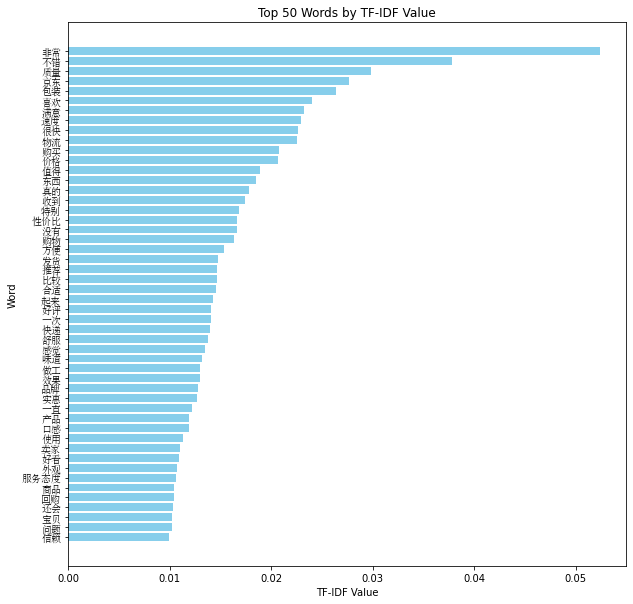

In [3]:
# TF-IDF 特征挖掘

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 文本数据
corpus = documents
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()
tfidf_means = X.mean(axis=0).tolist()[0]

# 将特征词和对应的TF-IDF值打包成元组并根据TF-IDF值降序排序
tfidf_tuples = [(feature, tfidf) for feature, tfidf in zip(feature_names, tfidf_means)]
tfidf_tuples.sort(key=lambda x: x[1], reverse=True)

# 取出前五十个词和对应的TF-IDF值
top_words = [word[0] for word in tfidf_tuples[:50]]
top_tfidf_values = [word[1] for word in tfidf_tuples[:50]]
my_font = font_manager.FontProperties(fname='SimSun.ttf')
plt.figure(figsize=(10, 10))
plt.barh(top_words, top_tfidf_values, color='skyblue')
plt.yticks(top_words,rotation=0,fontproperties=my_font,fontsize = 10)
plt.xlabel('TF-IDF Value')
plt.ylabel('Word')
plt.title('Top 50 Words by TF-IDF Value')
plt.gca().invert_yaxis()  # 反转y轴，使得值最高的词在上方显示
plt.show()


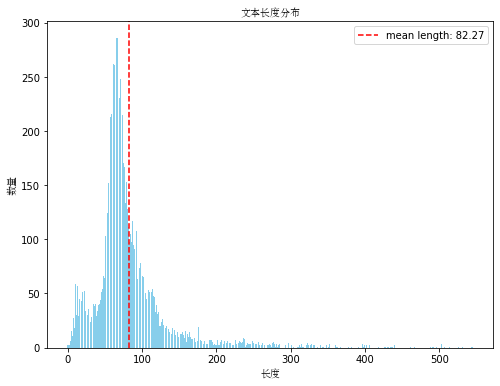

文本最短长度 0 文本最大长度 545


In [4]:
# 文本长度分布
from collections import Counter

string_arr = documents

length_counter = Counter(len(s) for s in string_arr)
lengths, counts = zip(*length_counter.items())


plt.figure(figsize=(8, 6))
plt.bar(lengths, counts, color='skyblue')

average_length = sum(length * count for length, count in length_counter.items()) / sum(counts)
plt.axvline(x=average_length, color='red', linestyle='--', label=f'mean length: {average_length:.2f}')

plt.xlabel('长度',font=font)
plt.ylabel('数量',font=font)
plt.title('文本长度分布',font=font)
plt.legend()
plt.show()
print(f'文本最短长度 {min(lengths)} 文本最大长度 {max(lengths)}')

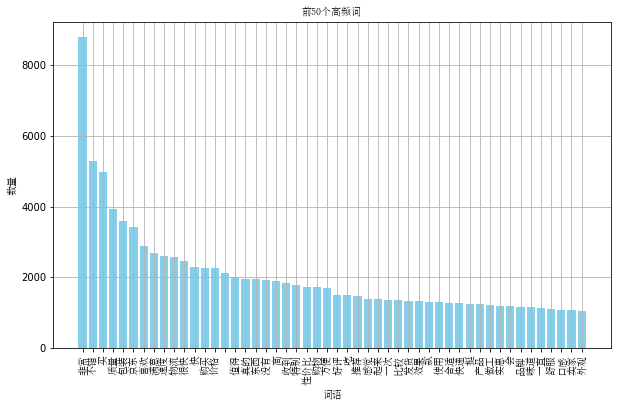

('非常', '不错', '买', '质量', '包装', '京东', '喜欢', '满意', '速度', '物流', '很快', '快', '购买', '价格', '', '值得', '真的', '东西', '没有', '高', '收到', '特别', '性价比', '购物', '方便', '好评', '吃', '推荐', '感觉', '起来', '一次', '比较', '发货', '效果', '款', '使用', '合适', '快递', '挺', '产品', '做工', '实惠', '会', '品牌', '味道', '一直', '舒服', '口感', '卖家', '外观')


In [6]:
# 统计高频字
with open('data/clean_sentence.txt','r') as file:
    lines = [line.strip().split(',')[1] for line in file.readlines()]
word_counts = Counter()

for line in lines:
    words = line.split(' ')
    word_counts.update(words)
# 分词并统计词频

# for string in string_arr:
#     seg_list = jieba.lcut(string)
#     word_counts.update(seg_list)
# 提取前50个高频词及其数量
top_words = word_counts.most_common(50)
words, counts = zip(*top_words)
# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(range(len(words)), counts, color='skyblue')
plt.xticks(range(len(words)), words, rotation=90,font=font)
plt.xlabel('词语',font=font)
plt.ylabel('数量',font=font)
plt.title('前50个高频词',font=font)
plt.grid()
plt.show()
print(words)




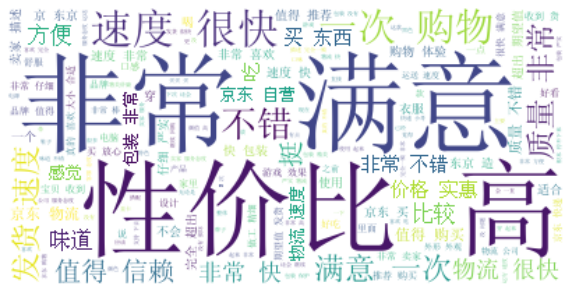

In [8]:
# 绘制所有文档的词云图
text = '\n'.join(documents)
wc = WordCloud(font_path='SimSun.ttf',background_color='white').generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
# plt.savefig('wordcloud.jpg') # 保存图片
plt.axis("off")
plt.show()